In [29]:
import json
import sys
from collections import defaultdict
from itertools import combinations
from pathlib import Path
import itertools
import numpy as np
import os

import pandas as pd
import torch
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns


In [30]:
MANIFOLDS = [
    "euclidean", # raw embeddings normalized to lie on the unit sphere, dimension d
    "lorentz_0.1_exp0", # raw embeddings projected to the Lorentz model using the exponential map at the origin, dimension d+1 (requires 0 padding)
    "lorentz_0.2_exp0",
    "lorentz_0.5_exp0",
    "lorentz_1_exp0",
    # "lorentz_2_exp0",
    # "lorentz_2.5_exp0",
    # "lorentz_5_exp0",
]

In [31]:
all_dirs = [
    "/media/AICF/hyperbolic_slots/slot_extractions_slotcontrast_dinov2",
    "/media/AICF/hyperbolic_slots/slot_extractions_videosaur_dinov2"
]

DATA_DIR = Path("/media/AICF/hyperbolic_slots/slot_extractions_slotcontrast_dinov2")
GT_PATH  = Path("/media/AICF/hyperbolic_slots/gt_slotcontrast_dinov2.json")
GT_KEY   = "gt_slotcontrast_dinov2"

In [32]:
data_dir = all_dirs[1]

In [33]:
def check_is_sphere(vectors):
    return torch.allclose(vectors.norm(dim=-1), torch.ones_like(vectors.norm(dim=-1)))

def check_is_lorentz(vectors, c=1.):
    inner_product = inner_lorentz(vectors, vectors)
    return torch.allclose(inner_product, -1./c * torch.ones_like(inner_product), atol=1e-5, rtol=1e-4)


In [34]:
def exp_map0(vectors, c=torch.tensor([1.])):
    # Exponential map at the origin for the Lorentz model
    # vectors: (batch_size, dim)
    # returns: (batch_size, dim+1)
    rc_norm = torch.sqrt(c) * vectors.norm(dim=-1, keepdim=True)
    time_component_at_origin = torch.sqrt(1./c)
    time_component = time_component_at_origin * torch.cosh(rc_norm)
    spacial_component = torch.sinh(rc_norm) * vectors / torch.clamp(rc_norm, min=1e-5)
    return torch.cat([time_component, spacial_component], dim=-1)
    
def inner_lorentz(x, y):
    # Inner product in the Lorentz model
    # x, y: (batch_size, dim+1)
    # returns: (batch_size,)
    return -x[..., 0] * y[..., 0] + torch.sum(x[..., 1:] * y[..., 1:], dim=-1)

def norm_lorentz(x, tol=1e-5):
    # Norm in the Lorentz model
    # x: (batch_size, dim+1)
    # returns: (batch_size,)
    return torch.sqrt(torch.clamp(torch.abs(inner_lorentz(x, x)), min=tol))


def projx_lorentz(x, c=1.):
    # Projection to the Lorentz model
    # x: (batch_size, dim)
    # returns: (batch_size, dim+1)
    rc_norm = torch.sqrt(c) * x.norm(dim=-1, keepdim=True)
    time_component = torch.sqrt(1./c + rc_norm**2)
    return torch.cat([time_component, x], dim=-1)


def get_origin_lorentz(dim, c=torch.tensor([1.]), dtype=torch.float32):
    time_component_at_origin = torch.sqrt(1./c)
    return torch.cat([time_component_at_origin * torch.ones(1, dtype=dtype), torch.zeros(dim-1, dtype=dtype)], dim=0)


def proj_to_tgz_lorentz(x, z, c=1.):
    # Projection of a point in space to the tangent space at the origin for the Lorentz model
    # x: (batch_size, dim)
    # returns: (batch_size, dim)
    return x + c * z * inner_lorentz(x, z).unsqueeze(-1)


def centroid_lorentz(points, c=1., tol=1e-5):
    # Compute the centroid of a set of points in the Lorentz model using standard mean
    # points: (num_points, dim+1)
    # returns: (dim+1,)
    mean = points.mean(dim=0)
    return mean / (norm_lorentz(mean, tol=tol) * torch.sqrt(c))


def distance_lorentz(x, y, c=1.0, eps=1e-7):
    # Distance in the Lorentz model
    # x, y: (batch_size, dim+1)
    inner_prod = inner_lorentz(x, y)
    z = -inner_prod * c
    z = torch.clamp(z, min=1.0 + eps)
    return torch.acosh(z) / torch.sqrt(torch.tensor(c, dtype=x.dtype, device=x.device))


def distance_norm_lorentz(x, y, c=1.):
    # Distance in the Lorentz model using the norm of the difference
    # x, y: (batch_size, dim+1)
    # returns: (batch_size,)
    diff = x - y
    return norm_lorentz(diff)

In [35]:
def stereographic_proj(x):
    # Stereographic projection to the sphere
    # x: (batch_size, dim)
    # returns: (batch_size, dim+1)
    norm_sq = x.norm(dim=-1, keepdim=True)**2
    time_component = (norm_sq - 1) / (norm_sq + 1)
    spacial_component = 2 * x / (norm_sq + 1)
    return torch.cat([time_component, spacial_component], dim=-1)

def distance_sphere(x, y):
    # Distance on the sphere with cosine similarity
    # x, y: (batch_size, dim+1)
    # returns: (batch_size,)
    inner_prod = torch.sum(x * y, dim=-1)
    return torch.acos(inner_prod.clamp(-1 + 1e-7, 1 - 1e-7))

In [36]:
def pairwise_dist(vectors, manifold_name):
    """Compute (N, N) geodesic distance matrix.

    Args:
        vectors: (N, D)
        manifold_name: one of MANIFOLDS.

    Returns:
        (N, N) distance tensor.
    """
    if manifold_name.startswith("lorentz"):
        c = float(manifold_name.split("_")[1])
        # Lorentz inner: -x0*y0 + x_rest @ y_rest^T → (P, C)
        inner = -vectors[:, 0:1] @ vectors[:, 0:1].T + vectors[:, 1:] @ vectors[:, 1:].T
        return torch.acosh((-inner * c).clamp(min=1.0)) / np.sqrt(c)
    else:
        norms = vectors.norm(dim=1, keepdim=True)
        cos_sim = vectors @ vectors.T / (norms @ norms.T)
        return torch.acos(cos_sim.clamp(-1 + 1e-7, 1 - 1e-7))

def distance(x, y, manifold_name, c=None):
    if manifold_name.startswith("lorentz"):
        c = torch.tensor(float(manifold_name.split("_")[1]), dtype=vectors.dtype)
        return distance_lorentz(x, y, c)
    else:
        return distance_sphere(x / x.norm(dim = 1, keepdim=True), y / y.norm())

In [37]:
def compute_centroid(vectors, manifold_name):
    """Manifold-appropriate centroid for the synthetic root.

    Args:
        vectors: (N, D) tensor on the manifold.
        manifold_name: one of MANIFOLDS.

    Returns:
        (D,) centroid tensor.
    """
    if manifold_name.startswith("lorentz"):
        c = torch.tensor(float(manifold_name.split("_")[1]), dtype=vectors.dtype)
        return centroid_lorentz(vectors, c=c)
    else:
        return vectors.mean(dim=0)

In [38]:
def get_origin(dim, manifold_name):
    if manifold_name.startswith("lorentz"):
        c = torch.tensor(float(manifold_name.split("_")[1]))
        return get_origin_lorentz(dim, c=c)
    else:
        return torch.zeros(dim)

In [39]:
def project_to_manifold(vectors, manifold):
    vectors = vectors.to(torch.float64)
    if manifold == "euclidean":
        return vectors
    elif manifold == "sphere":
        vectors = vectors / torch.norm(vectors, dim=-1, keepdim=True)
        assert check_is_sphere(vectors), "Projection to sphere failed, not all vectors have norm 1"
        return vectors
    elif manifold.endswith("_exp0"):
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        vectors = exp_map0(vectors, c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors
    elif manifold == "lorentz_1_projx":
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        vectors = projx_lorentz(vectors, c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors
    elif manifold == "sphere_estereographic":
        vectors = stereographic_proj(vectors)
        assert check_is_sphere(vectors), "Projection to sphere failed, not all vectors have norm 1"
        return vectors
    elif manifold == "lorentz_1_exp0_restricted":
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        origin = get_origin_lorentz(vectors.shape[-1], c=c, dtype=vectors.dtype)
        proj_vectors = proj_to_tgz_lorentz(vectors, origin, c=c)
        assert torch.all(proj_vectors[:, 0] == 0), "Projection to tangent space slot_extractions_videosaur_dinov2at origin failed, time component is not 0"
        vectors = exp_map0(proj_vectors[:, 1:], c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors
    elif manifold == "lorentz_1_projx_restricted":
        c = torch.tensor(float(manifold.split("_")[1]), dtype=vectors.dtype)
        vectors = projx_lorentz(vectors[:, 1:], c=c)
        assert check_is_lorentz(vectors, c=c), "Projection to Lorentz failed, not all vectors satisfy the Lorentz condition"
        return vectors

        
    else: 
        raise ValueError(f"Unknown manifold: {manifold}")
        

        

In [40]:
# for data_dir in all_dirs:
print(f"Processing directory: {data_dir}")
data_dir = Path(data_dir)

video_dirs = sorted(d for d in data_dir.iterdir() if d.is_dir() and (d.name.startswith("video_") or d.name.startswith("image_")))
print(f"Found {len(video_dirs)} instances in {data_dir}")

embeddings_info = defaultdict(dict)

for video_dir in tqdm(video_dirs, desc=f"Processing videos in {data_dir.name}"):
    # Take files of form slots_raw_*.pt
    all_slots = list(video_dir.glob("slots_raw_*.pt"))
    embeddings_info[video_dir.name] = defaultdict(dict)
    for slots in all_slots:
        # embeddings_info[video_dir.name][slots.stem] = defaultdict(dict)
        with open(slots, "rb") as f:
            data = torch.load(f)
            # Only keep the last frame if it is not coco
            if "coco" not in data_dir.stem:
                embeddings_info[video_dir.name]["raw"][slots.stem.split("_")[-1]] = data[-1]
            else:
                embeddings_info[video_dir.name]["raw"][slots.stem.split("_")[-1]] = data
        for manifold in MANIFOLDS:
            projected = project_to_manifold(
                embeddings_info[video_dir.name]["raw"][slots.stem.split("_")[-1]].to(torch.float64),
                manifold,
            )
            embeddings_info[video_dir.name][f"{manifold}"][slots.stem.split("_")[-1]] = projected


# Save the embeddings info to a .pt file
print(f"Saving embeddings info for {data_dir}...")
output_file = data_dir / "embeddings_info.pt"
with open(output_file, "wb") as f:
    torch.save(embeddings_info, f)

Processing directory: /media/AICF/hyperbolic_slots/slot_extractions_videosaur_dinov2
Found 300 instances in /media/AICF/hyperbolic_slots/slot_extractions_videosaur_dinov2


Processing videos in slot_extractions_videosaur_dinov2: 100%|██████████| 300/300 [00:34<00:00,  8.75it/s]


Saving embeddings info for /media/AICF/hyperbolic_slots/slot_extractions_videosaur_dinov2...


In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# Hit@1 and Hit@3 — Parent Retrieval Evaluation
# For each fine slot s_j: rank all coarse slots by distance, check if GT parent
# is rank 1 (hit@1) or in top 3 (hit@3). Evaluated for all manifolds.
# ═══════════════════════════════════════════════════════════════════════════════

import json
import gc
import numpy as np
import torch
import pandas as pd
from collections import defaultdict
from pathlib import Path
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────────────
# DATA_DIR = Path("/media/AICF/hyperbolic_slots/slot_extractions_slotconstrast_dinov2")
# GT_PATH  = Path("/media/AICF/hyperbolic_slots/gt_slotcontrast_dinov2.json")
# GT_KEY   = "gt_slotcontrast_dinov2"

# DATA_DIR = Path("../data_upload/slot_extractions_spot_coco")
# GT_PATH  = Path("../data_upload/gt_spot_coco.json")
# GT_KEY   = "gt_spot_coco"

DATA_DIR = Path("/media/AICF/hyperbolic_slots/slot_extractions_videosaur_dinov2")
GT_PATH  = Path("/media/AICF/hyperbolic_slots/gt_videosaur_dinov2.json")
GT_KEY   = "gt_videosaur_dinov2"

MANIFOLDS_EVAL = [
    "euclidean",
    "lorentz_0.1_exp0",
    "lorentz_0.2_exp0",
    "lorentz_0.5_exp0",
    "lorentz_1_exp0",
    "lorentz_2_exp0",
]
GT_TRANSITIONS = [(3, 5), (5, 7), (7, 11), (11, 13)]  # adjacent levels only
# ─────────────────────────────────────────────────────────────────────────────

# Load GT and build: gt_assign[video][(p_lvl, c_lvl)][child_idx] = parent_idx
with open(GT_PATH) as f:
    gt_raw = json.load(f)[GT_KEY]

gt_assign = {}
for video_name, video_gt in gt_raw.items():
    gt_assign[video_name] = {}                  # initialize for each video
    for p_lvl, c_lvl in GT_TRANSITIONS:         # only consider adjacent levels for parent retrieval evaluation
        key = f"{p_lvl}_to_{c_lvl}"             # GT keys are of the form "3_to_5", "5_to_7", etc.
        if key not in video_gt:                 # if this transition is not present for the video, skip it
            continue
        assign = {}                             # child_idx → parent_idx mapping for this video and this level transition
        for parent_label, children in video_gt[key].items():   # parent_label is of the form "parent_{idx}" and children is a list of labels like "child_{idx}"        
            p_idx = int(parent_label.split("_")[1])            # extract index from "parent_{idx}"
            for child_label in children:                       #    extract index from each child label and build the mapping
                c_idx = int(child_label.split("_")[1])         
                assign[c_idx] = p_idx                           # child_idx → parent_idx, so instead of assign[parent] = child (whic is string), we do assign[child_idx] = parent_idx for easier evaluation later
        gt_assign[video_name][(p_lvl, c_lvl)] = assign         # store the mapping for this video and this level transition
del gt_raw


def cross_dist(child_vecs, parent_vecs, manifold_name):
    """(C, P) distance matrix between child and parent slot vectors."""
    if manifold_name.startswith("lorentz"): 
        c = float(manifold_name.split("_")[1])  # extract curvature from manifold name
        inner = (-child_vecs[:, 0:1] * parent_vecs[:, 0:1].T  # time component
                 + child_vecs[:, 1:] @ parent_vecs[:, 1:].T) # Lorentz inner product → (C, P)
        return torch.acosh((-inner * c).clamp(min=1.0)) / np.sqrt(c)  # Lorentz distance
    else:  # euclidean: geodesic on unit sphere = arccos of cosine similarity
        cn = child_vecs  / child_vecs.norm(dim=1, keepdim=True).clamp(min=1e-8)  # normalize child vectors to lie on unit sphere
        pn = parent_vecs / parent_vecs.norm(dim=1, keepdim=True).clamp(min=1e-8) # normalize parent vectors to lie on unit sphere
        return torch.acos((cn @ pn.T).clamp(-1 + 1e-7, 1 - 1e-7)) # distance on unit sphere


# Load embeddings and run retrieval
print("Loading embeddings_info...")
embeddings_info = torch.load(DATA_DIR / "embeddings_info.pt", weights_only=False)

hits = defaultdict(lambda: defaultdict(lambda: {"h1": [], "h3": []}))

for video_name, video_data in tqdm(embeddings_info.items(), desc="Evaluating Hit@k"):
    if video_name not in gt_assign:  # if we don't have GT for this video, skip it
        continue
    for manifold_name in MANIFOLDS_EVAL:
        if manifold_name not in video_data:
            continue
        mdata = video_data[manifold_name]   # dict with keys like "3", "5", "7", "11", "13" → (N, D) tensors
        for (p_lvl, c_lvl), assign in gt_assign[video_name].items():  # only consider adjacent levels for parent retrieval evaluation
            if not assign:      # if there are no GT pairs for this video and this level transition, skip it
                continue        # if assign is empty, it means there are no child-parent pairs for this video and this level transition, so we skip the evaluation for this case
            p_key, c_key = str(p_lvl), str(c_lvl)
            #print(f"Evaluating {video_name} {manifold_name} L{p_lvl}→L{c_lvl} with {len(assign)} GT pairs...")
            if p_key not in mdata or c_key not in mdata:
                continue
            pvecs  = mdata[p_key].to(torch.float64)          # (P, D)
            cvecs  = mdata[c_key].to(torch.float64)          # (C, D)
            #print(f"  Child vectors shape: {cvecs.shape}, Parent vectors shape: {pvecs.shape}")
            dists  = cross_dist(cvecs, pvecs, manifold_name) # (C, P)
            ranked = dists.argsort(dim=1)                    # ascending: nearest first

            for c_idx, p_idx_gt in assign.items():
                if c_idx >= cvecs.shape[0] or p_idx_gt >= pvecs.shape[0]:
                    continue
                rank = (ranked[c_idx] == p_idx_gt).nonzero(as_tuple=True)[0].item()
                hits[(p_lvl, c_lvl)][manifold_name]["h1"].append(int(rank == 0))
                hits[(p_lvl, c_lvl)][manifold_name]["h3"].append(int(rank < 3))

del embeddings_info
gc.collect()

# ── Results table ─────────────────────────────────────────────────────────────
rows = []
for (p_lvl, c_lvl) in GT_TRANSITIONS:
    for manifold_name in MANIFOLDS_EVAL:
        r = hits[(p_lvl, c_lvl)][manifold_name]
        if not r["h1"]:
            continue
        n  = len(r["h1"])
        h1 = 100 * sum(r["h1"]) / n
        h3 = 100 * sum(r["h3"]) / n
        rows.append({
            "Transition": f"L{p_lvl}→L{c_lvl}",
            "Manifold":   manifold_name,
            "Hit@1 (%)":  round(h1, 1),
            "Hit@3 (%)":  round(h3, 1),
            "N":          n,
        })

df = pd.DataFrame(rows)
print("\n", df.pivot_table(
    index="Transition", columns="Manifold",
    values=["Hit@1 (%)", "Hit@3 (%)"]
).to_string())

Loading embeddings_info...


Evaluating Hit@k: 100%|██████████| 300/300 [00:01<00:00, 250.51it/s]



            Hit@1 (%)                                                                   Hit@3 (%)                                                                  
Manifold   euclidean lorentz_0.1_exp0 lorentz_0.2_exp0 lorentz_0.5_exp0 lorentz_1_exp0 euclidean lorentz_0.1_exp0 lorentz_0.2_exp0 lorentz_0.5_exp0 lorentz_1_exp0
Transition                                                                                                                                                        
L11→L13         88.1             88.1             88.1             88.1           88.0      95.2             95.1             94.9             94.6           94.2
L3→L5           91.5             91.5             91.9             91.3           90.8     100.0            100.0            100.0            100.0          100.0
L5→L7           93.2             93.4             93.3             92.8           92.4      99.2             99.2             99.1             98.9           98.7
L7→L11          88.6

Loading embeddings for this video...


/tmp/ipykernel_741840/1434266759.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


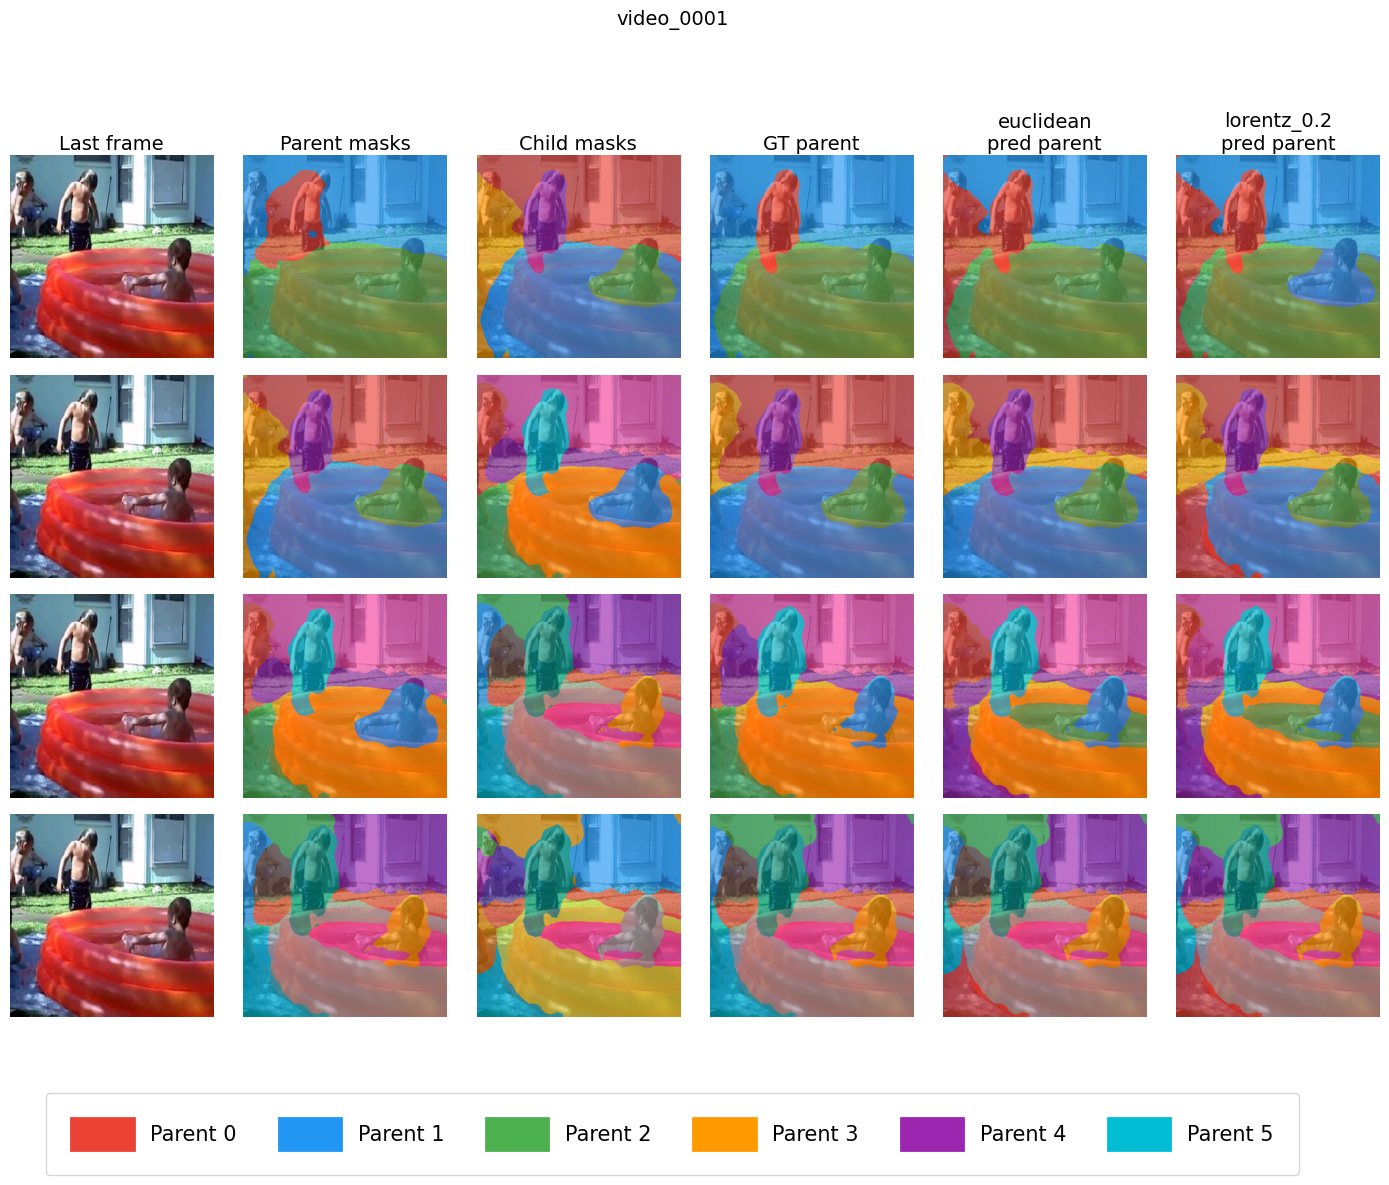

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# Visualize parent-child hierarchy: GT vs predicted (euclidean & lorentz)
# Columns: Last frame | Parent masks | Child masks | GT coloring | Eucl pred | Lor pred
# Each child pixel is colored by the parent slot it is assigned to.
# If GT and pred match → same color.
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
from PIL import Image

# ── Config ────────────────────────────────────────────────────────────────────
VIDEO_NAME    = "video_0001"   # change to any video_XXXX
VIZ_MANIFOLDS = ["euclidean", "lorentz_0.2_exp0"]
TRANSITIONS   = [(3, 5), (5, 7), (7, 11), (11, 13)]

COLORS = np.array([
    [0.92, 0.26, 0.21],  # red
    [0.13, 0.59, 0.95],  # blue
    [0.30, 0.69, 0.31],  # green
    [1.00, 0.60, 0.00],  # orange
    [0.61, 0.15, 0.69],  # purple
    [0.00, 0.74, 0.83],  # cyan
    [0.96, 0.26, 0.62],  # pink
    [0.47, 0.33, 0.28],  # brown
    [0.62, 0.62, 0.62],  # grey
    [0.80, 0.86, 0.22],  # lime
    [0.00, 0.59, 0.53],  # teal
    [0.40, 0.23, 0.72],  # indigo
    [0.90, 0.45, 0.00],  # amber
])

def color_by_slot(mask_hw, n_slots):
    """(H,W) int mask → (H,W,3) RGB, each slot gets its own color."""
    H, W = mask_hw.shape
    rgb = np.zeros((H, W, 3))
    for s in range(n_slots):
        rgb[mask_hw == s] = COLORS[s % len(COLORS)]
    return rgb

def color_by_parent(child_mask_hw, child_to_parent):
    """(H,W) child mask + {c_idx→p_idx} → (H,W,3) RGB colored by parent."""
    H, W = child_mask_hw.shape
    rgb = np.ones((H, W, 3)) * 0.85   # light grey for unassigned
    for c_idx, p_idx in child_to_parent.items():
        rgb[child_mask_hw == c_idx] = COLORS[p_idx % len(COLORS)]
    return rgb

def blend(mask_rgb, frame_np, alpha=0.65):
    """Blend mask colors with the original frame."""
    return alpha * mask_rgb + (1 - alpha) * frame_np

# ── Load data ─────────────────────────────────────────────────────────────────
vid_dir  = DATA_DIR / VIDEO_NAME
frame_np = np.array(Image.open(vid_dir / "last_frame.jpg").resize((518, 518))) / 255.0


print("Loading embeddings for this video...")
embeddings_info = torch.load(DATA_DIR / "embeddings_info.pt", weights_only=False)
vdata = embeddings_info[VIDEO_NAME]
del embeddings_info

masks = {}
for lvl in [3, 5, 7, 11, 13]:
    masks[lvl] = torch.load(vid_dir / f"masks_hard_{lvl}.pt", weights_only=False)[-1].numpy()

# ── Compute predicted assignments ─────────────────────────────────────────────
pred_assign = {m: {} for m in VIZ_MANIFOLDS}
for manifold_name in VIZ_MANIFOLDS:
    mdata = vdata[manifold_name]
    for p_lvl, c_lvl in TRANSITIONS:
        p_key, c_key = str(p_lvl), str(c_lvl)
        if p_key not in mdata or c_key not in mdata:
            continue
        pvecs = mdata[p_key].to(torch.float64)
        cvecs = mdata[c_key].to(torch.float64)
        dists = cross_dist(cvecs, pvecs, manifold_name)   # (C, P)
        pred  = dists.argmin(dim=1)                        # (C,)
        pred_assign[manifold_name][(p_lvl, c_lvl)] = {c: pred[c].item() for c in range(len(pred))}

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = 4 + len(VIZ_MANIFOLDS)   # frame | parent | child | GT | manifold*N
n_rows = len(TRANSITIONS)
col_titles = (["Last frame", "Parent masks", "Child masks", "GT parent"]
              + [m.replace("_exp0", "") + "\npred parent" for m in VIZ_MANIFOLDS])

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.0, n_rows * 2.8))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.0, n_rows * 2.8),
                         gridspec_kw={"wspace": 0.02, "hspace": 0.08})

fig.suptitle(f"{VIDEO_NAME}", fontsize=14, y=1.01)

for row, (p_lvl, c_lvl) in enumerate(TRANSITIONS):
    axrow  = axes[row]
    p_mask = masks[p_lvl]    # (H, W)
    c_mask = masks[c_lvl]    # (H, W)
    gt     = gt_assign.get(VIDEO_NAME, {}).get((p_lvl, c_lvl), {})

    # Col 0: last frame
    axrow[0].imshow(frame_np)
    axrow[0].set_ylabel(f"L{p_lvl}→L{c_lvl}", fontsize=14)

    # Col 1: parent slot masks (each slot own color)
    axrow[1].imshow(blend(color_by_slot(p_mask, p_lvl), frame_np))

    # Col 2: child slot masks (each slot own color)
    axrow[2].imshow(blend(color_by_slot(c_mask, c_lvl), frame_np))

    # Col 3: GT — child pixels colored by GT parent
    if gt:
        axrow[3].imshow(blend(color_by_parent(c_mask, gt), frame_np))
    else:
        axrow[3].text(0.5, 0.5, "No GT", ha="center", va="center",
                      transform=axrow[3].transAxes, fontsize=14)

    # Col 4+: predicted parent coloring per manifold
    for col_off, manifold_name in enumerate(VIZ_MANIFOLDS):
        pa = pred_assign[manifold_name].get((p_lvl, c_lvl), {})
        ax = axrow[4 + col_off]
        if pa:
            ax.imshow(blend(color_by_parent(c_mask, pa), frame_np))
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14)

    for ax in axrow:
        ax.axis("off")

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=14, pad=4)

# # Legend: parent slot colors (up to max parent count = 11)
# max_parents = max(p for p, _ in TRANSITIONS)
# patches = [mpatches.Patch(color=COLORS[i], label=f"Parent {i}") for i in range(max_parents)]
# fig.legend(handles=patches, loc="lower center", ncol=max_parents,
#            fontsize=14, bbox_to_anchor=(0.5, -0.02))

# Legend: parent slot colors — two rows (0-4 and 5-10)
max_parents = max(p for p, _ in TRANSITIONS)
patches = [mpatches.Patch(color=COLORS[i], label=f"Parent {i}", linewidth=2) for i in range(max_parents)]
fig.legend(handles=patches[:6], loc="lower center", ncol=6,
           fontsize=15, bbox_to_anchor=(0.5, -0.04),
           handleheight=2.0, handlelength=3.0, borderpad=1.2)
# fig.legend(handles=patches[5:], loc="lower center", ncol=5,
#            fontsize=15, bbox_to_anchor=(0.5, -0.10),
#            handleheight=2.0, handlelength=3.0, borderpad=1.2)


plt.tight_layout()
plt.show()